# Diabetes Prediction

In [433]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Problem Statement

Diabetes merupakan kelainan metabolisme yang ditandai dengan tingginya kadar gula darah dalam jangka waktu lama. Gejala gula darah tinggi antara lain sering buang air kecil, rasa haus yang meningkat, dan rasa lapar yang meningkat. Jika tidak diobati, diabetes dapat menyebabkan banyak komplikasi. Untuk menentukan apakah seseorang menderita diabetes diperlukan diagnosis. 

Seringkali diagnosis sulit dilakukan karena banyak indikasi dan gejala yang tidak jelas dan hanya dapat dianalisis oleh ahli kesehatan yang terlatih dan sering kali memerlukan tes kesehatan yang dianggap cukup mahal. Selain itu, Manusia juga rentan terhadap kesalahan, sehingga tidak heran jika diagnosis berlebihan sering terjadi pada pasien.

## Goals

Berdasarkan permasalahan di atas, maka diperlukan sebuah *prediction tool* yang dapat memprediksi secara diagnostik apakah seseorang menderita diabetes atau tidak berdasarkan pengukuran diagnostik tertentu.

## Data Understanding

In [434]:
# Load dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [435]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## Exploratory Data Analysis

### Data Distribution

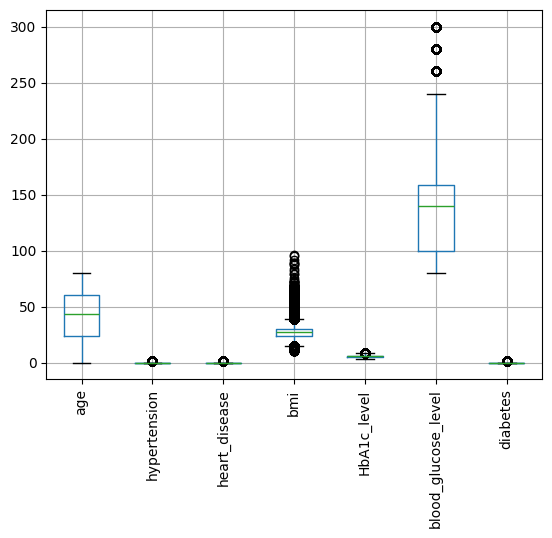

In [436]:
# Outliers dari setiap fitur numerik
df.boxplot(rot=90)
plt.show()

Berdasarkan plot di atas, semua fitur memiliki outliers terkecuali fitur `age`. Fitur `bmi` memiliki outliers yang paling tinggi.

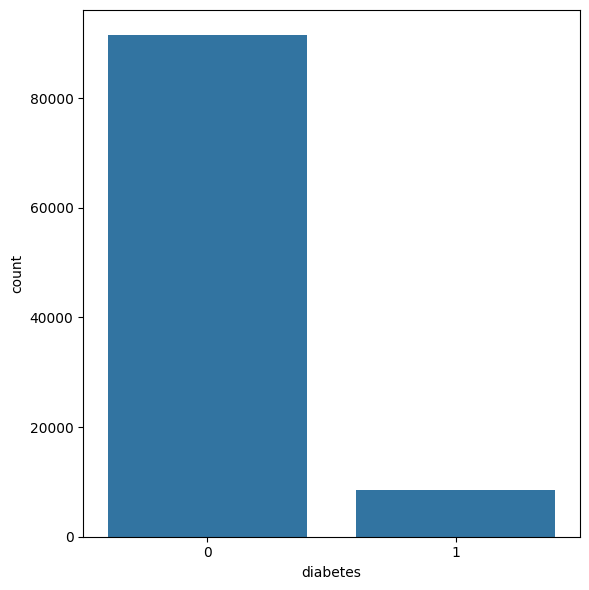

In [437]:
# Jumlah penderita diabetes dan non diabetes dari dataset
plt.figure(figsize=(6,6))
sns.countplot(x=df['diabetes'], order = df['diabetes'].value_counts().index)
plt.tight_layout()
plt.show()

In [438]:
df['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

Berdasarkan plot di atas, dapat dilihat bahwa terdapat ketidakseimbangan data antara jumlah penderita diabetes dan non diabates, dimana jumlah non diabetes jauh lebih banyak dibandingkan penderita diabetes.

## Data Preprocessing

In [439]:
df_diabet = df.copy()

### Data Duplikat

In [440]:
#Mengecek data duplikat
df_diabet.duplicated().sum()

3854

In [441]:
# Menghapus data duplikat
df_diabet.drop_duplicates(inplace=True)

### Missing Value

In [442]:
df_diabet.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Tidak ada missing value pada dataset.

### Statistik Deskriptif

In [443]:
df_diabet.describe(include='all')

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146,96146.000000,96146.000000,96146.000000,96146,96146.000000,96146.000000,96146.000000,96146.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,never,NaN,NaN,NaN,NaN
freq,56161,NaN,NaN,NaN,34398,NaN,NaN,NaN,NaN
mean,NaN,41.794326,0.077601,0.040803,NaN,27.321461,5.532609,138.218231,0.088220
std,NaN,22.462948,0.267544,0.197833,NaN,6.767716,1.073232,40.909771,0.283616
min,NaN,0.080000,0.000000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.000000,0.000000,NaN,23.400000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.000000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,59.000000,0.000000,0.000000,NaN,29.860000,6.200000,159.000000,0.000000


### Data Correlation

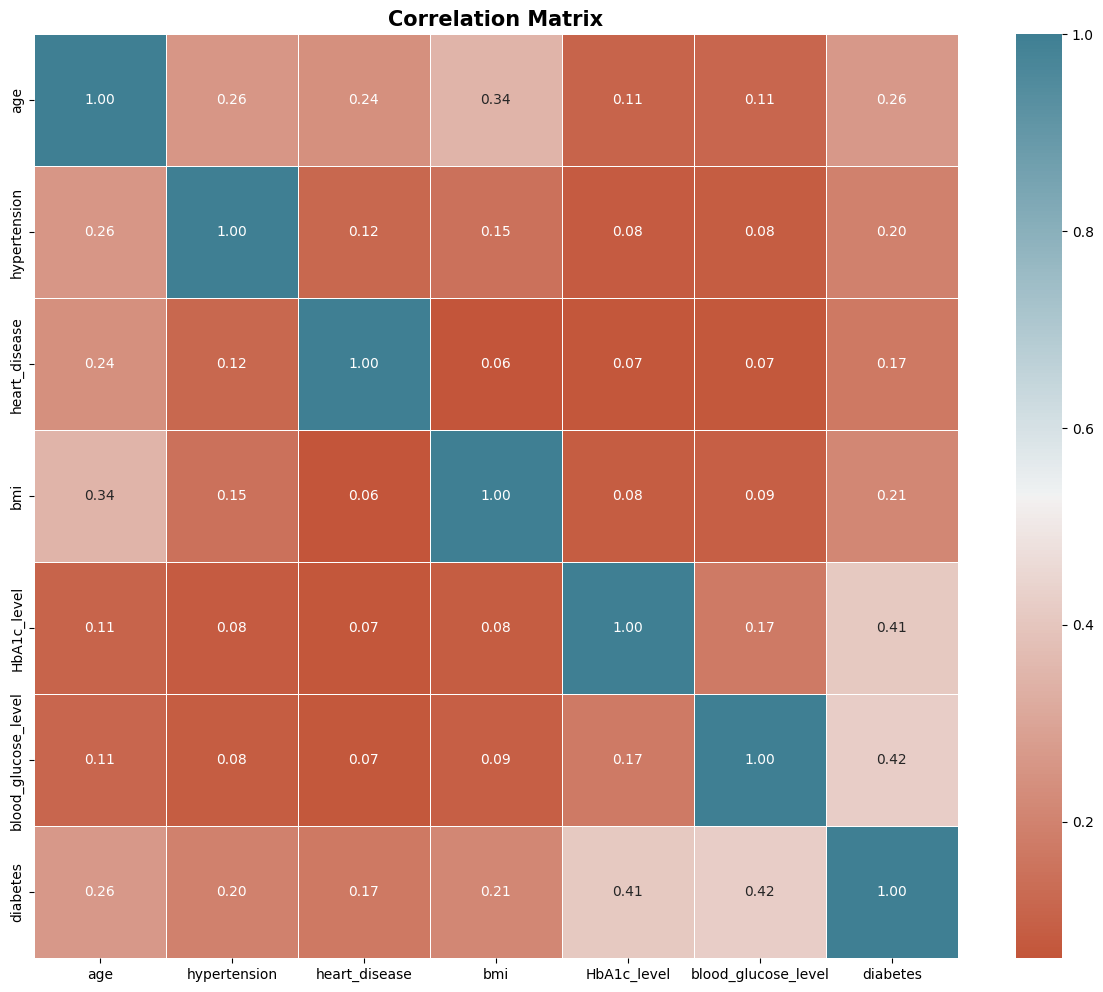

In [444]:
# Correlation matrix
plt.figure(figsize=(15, 12))
palette=sns.diverging_palette(20, 220, n=256)
corr = df_diabet.corr(method='pearson', numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=palette, square=True, linewidths=.5)
plt.title('Correlation Matrix', size=15, weight='bold');
plt.show()

Berdasarkan hasil korelasi di atas, tidak ada fitur lain yang memiliki korelasi yang cukup kuat terhadap fitur diabetes.

### Outliers

In [445]:
# Check outliers
def check_outliers(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    limit = iqr*1.5
    print(f'IQR: {iqr}')

    limit_bawah = q1 - limit
    limit_atas = q3 + limit
    print(f'limit_bawah: {limit_bawah}')
    print(f'limit_atas: {limit_atas}')  

#### Fitur bmi

In [446]:
check_outliers(df_diabet['bmi'])

IQR: 6.460000000000001
limit_bawah: 13.709999999999997
limit_atas: 39.55


In [447]:
df_diabet['bmi'].describe()

count    96146.000000
mean        27.321461
std          6.767716
min         10.010000
25%         23.400000
50%         27.320000
75%         29.860000
max         95.690000
Name: bmi, dtype: float64

In [448]:
df_diabet[df_diabet['bmi']>39.55].count()['bmi']

4940

Fitur `bmi` memiliki outliers sebanyak 4940. Namun outlier ini tidak akan dihapus karena nilai BMI lebih dari 39.55 memiliki kemungkinan diabetes yang cukup besar, sehingga jika dihilangkan akan menghapus banyak informasi. 

#### Fitur HbA1c_level

In [449]:
check_outliers(df_diabet['HbA1c_level'])

IQR: 1.4000000000000004
limit_bawah: 2.6999999999999993
limit_atas: 8.3


In [450]:
df_diabet['HbA1c_level'].describe()

count    96146.000000
mean         5.532609
std          1.073232
min          3.500000
25%          4.800000
50%          5.800000
75%          6.200000
max          9.000000
Name: HbA1c_level, dtype: float64

In [451]:
df_diabet[df_diabet['HbA1c_level']>8.3].count()['HbA1c_level']

1312

Fitur `HbA1c` memiliki outliers sebanyak 1312. Namun outlier ini tidak akan dihapus karena tingkat HbA1c lebih dari 8.3 memiliki kemungkinan diabetes yang cukup besar, sehingga jika dihilangkan akan menghapus banyak informasi. 

#### Fitur blood_glucose_level

In [452]:
check_outliers(df_diabet['blood_glucose_level'])

IQR: 59.0
limit_bawah: 11.5
limit_atas: 247.5


In [453]:
df_diabet['blood_glucose_level'].describe()

count    96146.000000
mean       138.218231
std         40.909771
min         80.000000
25%        100.000000
50%        140.000000
75%        159.000000
max        300.000000
Name: blood_glucose_level, dtype: float64

In [454]:
df_diabet[df_diabet['blood_glucose_level']>247.5].count()['blood_glucose_level']

2031

Fitur `blood_glucose_level` memiliki outliers sebanyak 2031. Namun outlier ini tidak akan dihapus karena level gula darah lebih dari 247.5 memiliki kemungkinan diabetes yang cukup besar, sehingga jika dihilangkan akan menghapus banyak informasi. 

## Data Analysis

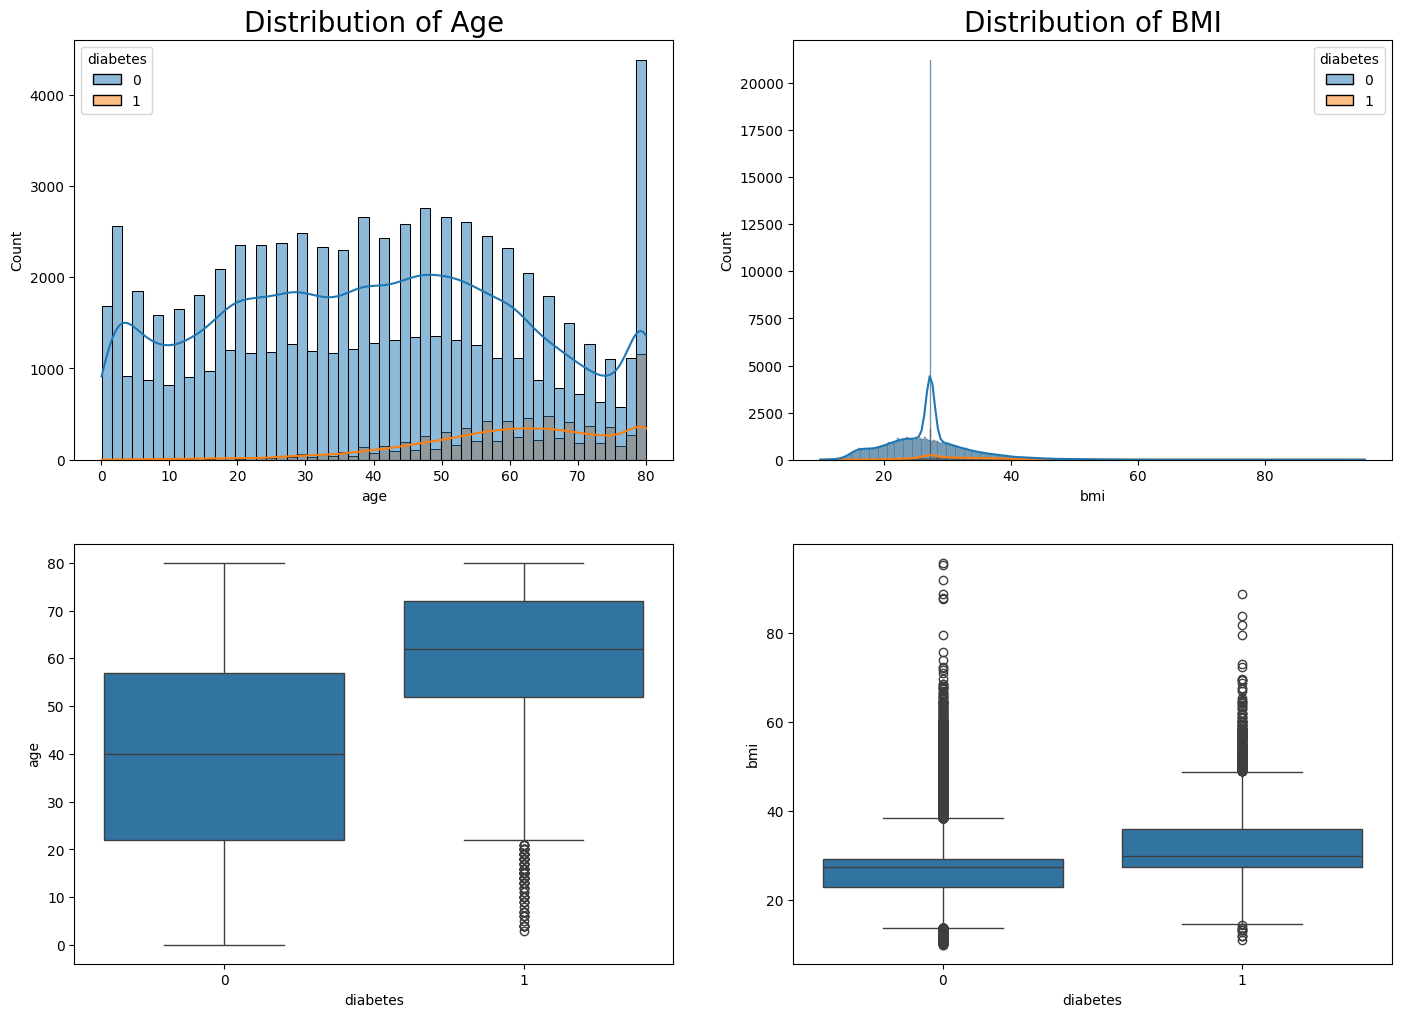

In [455]:
plt.figure(figsize=(17,12))

plt.subplot(221)
sns.histplot(data=df_diabet,x='age',hue='diabetes',kde=True)
plt.title('Distribution of Age',fontsize=20)

plt.subplot(222)
sns.histplot(data=df_diabet,x='bmi',hue='diabetes',kde=True)
plt.title('Distribution of BMI',fontsize=20)

plt.subplot(223)
sns.boxplot(data=df_diabet,y='age', x='diabetes')

plt.subplot(224)
sns.boxplot(data=df_diabet,y='bmi', x='diabetes')
plt.show()

Berdasarkan plot di atas, dapat dilihat bahwa penderita diabetes lebih banyak ada pada usia yang lebih tua. Begitupun dengan BMI, penderita diabetes lebih banyak terjadi pada BMI yang cukup besar.

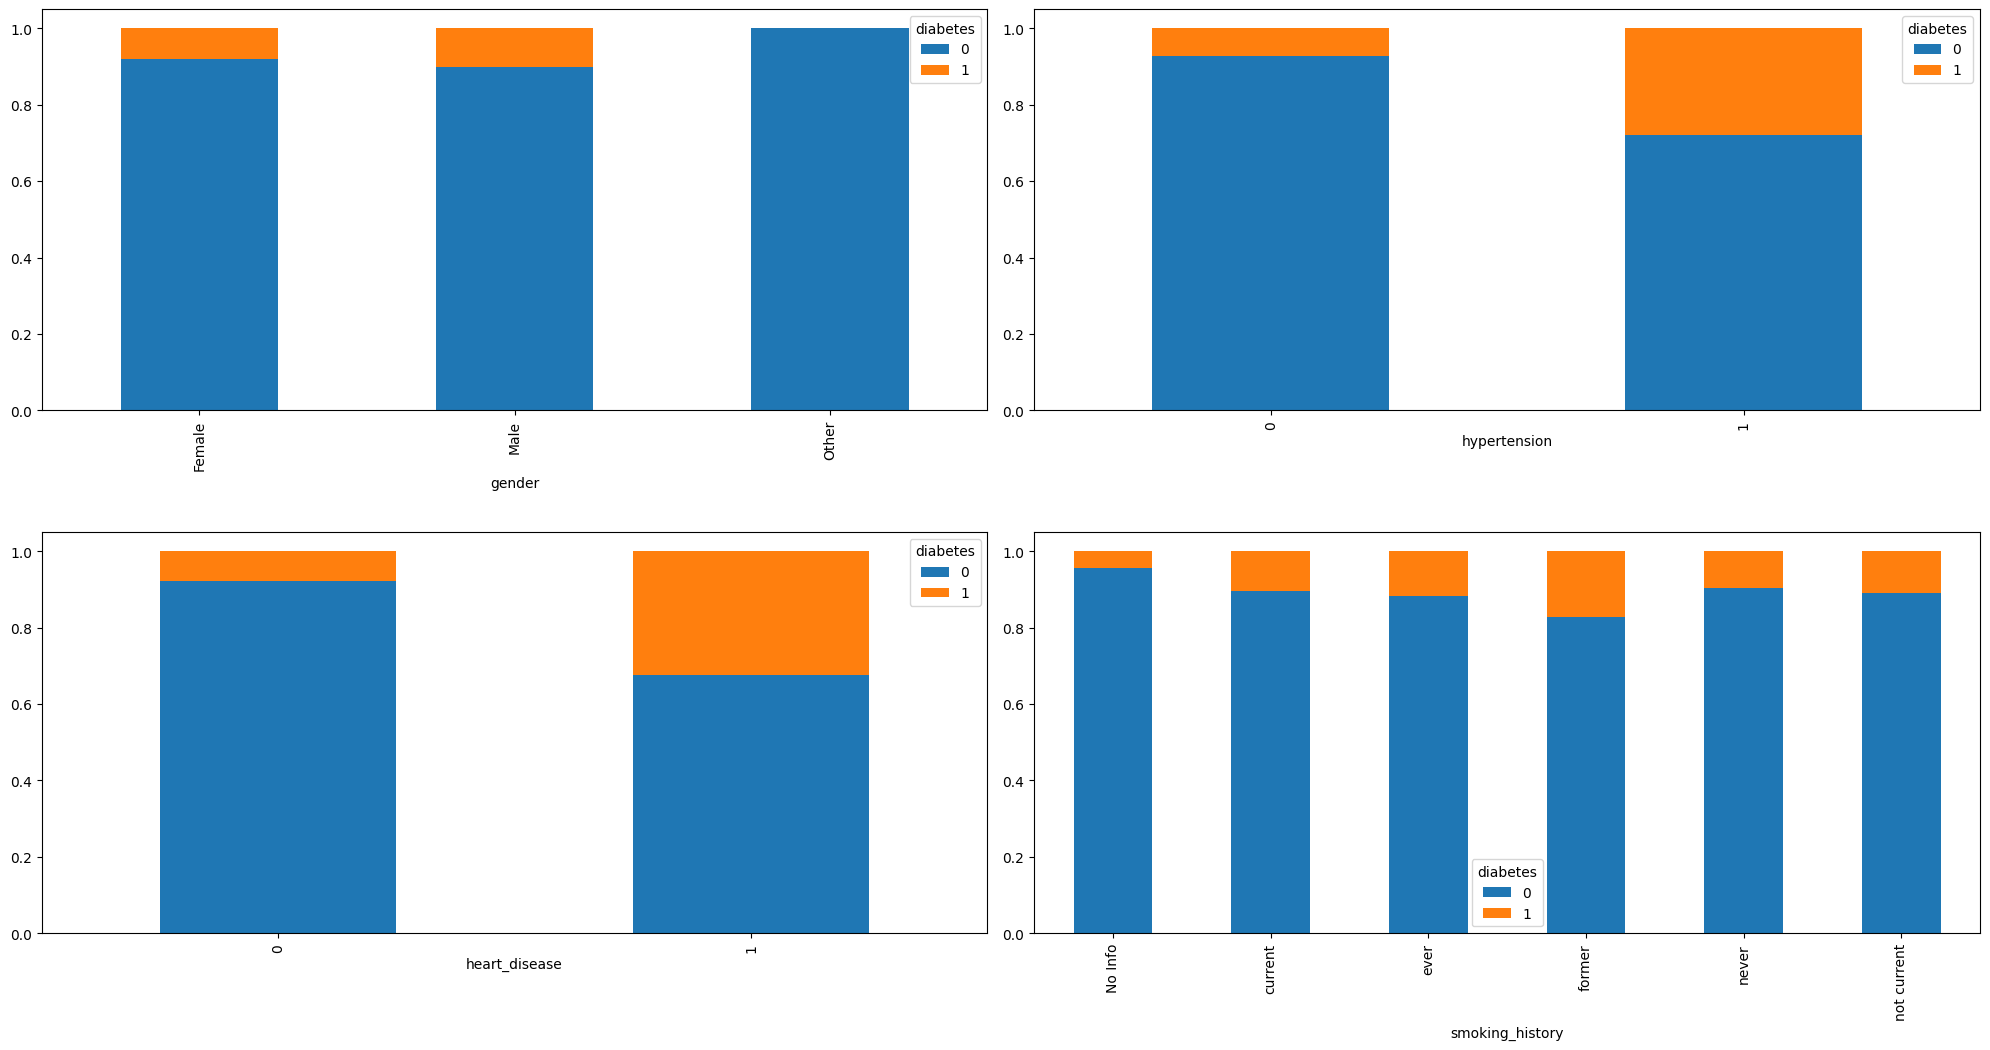

In [456]:
categories = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
count = 0
fig = plt.figure(figsize=(20,20))

for i in categories:
    count +=1
    ax= plt.subplot(4,2,count)
    pd.crosstab(df_diabet[i],df_diabet['diabetes'],normalize=0).plot(kind='bar',stacked=True,ax=ax)
    fig.tight_layout()

plt.show()

In [457]:
for i in categories:
    cat_df_diabet = df_diabet.groupby(i)['diabetes'].value_counts(normalize=True).unstack()
    display(cat_df_diabet.sort_values(by=[1.0], ascending=False))

diabetes,0,1
gender,,
Male,0.899042,0.100958
Female,0.920817,0.079183
Other,1.000000,NaN


diabetes,0,1
hypertension,,
1,0.720413,0.279587
0,0.927880,0.072120


diabetes,0,1
heart_disease,,
1,0.677033,0.322967
0,0.921766,0.078234


diabetes,0,1
smoking_history,,
former,0.829014,0.170986
ever,0.881941,0.118059
not current,0.891629,0.108371
current,0.896923,0.103077
never,0.902989,0.097011
No Info,0.956062,0.043938


Berdasarkan plot dan tabel di atas dapat diperoleh:
* Berdasarkan gender, laki-laki lebih banyak menderita diabetes daripada perempuan
* Berdasarkan riwayat hipertensi, orang dengan riwayat hipertensi lebih banyak menderita diabetes
* Berdasarkan riwayat penyakit jantung, orang dengan riwayat penyakit jantung lebih banyak menderita diabetes
* Berdasarkan riwayat merokok, *former* lebih banyak menderita diabetes

## Modelling

In [458]:
# Library untuk Modelling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Imbalance Dataset
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

### Feature Engineering

In [459]:
# variabel kategorik untuk dilakukan one hot encoding
one_hot_var = ['gender', 'smoking_history']

# variabel numerik untuk di scalling menggunakan robust scaler
scaling_var = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# variabel berisikan pipeline untuk encoding
one_hot_encoding = Pipeline([('encoding_onehotencoding',OneHotEncoder(drop='first', handle_unknown='ignore'))])

# variabel berisikan pipeline untuk scaling
scaling = Pipeline(steps=[('scaling',RobustScaler())])

# Menggabungkan pipeline encoding dan pipeline scaling
transformer = ColumnTransformer([
        ('transformation_categorical', one_hot_encoding, one_hot_var),
        ('transformation_numerical', scaling, scaling_var)],remainder='passthrough')

In [460]:
# Memisahkan data independen variabel dengan target
x = df_diabet.drop(['diabetes'], axis=1)
y = df_diabet['diabetes']

In [461]:
# Splitting data training dan test dengan proporsi 70:30
x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,  
    stratify=y,
    test_size=0.3,
    random_state=2020)

In [462]:
testing = pd.DataFrame(transformer.fit_transform(x_train),columns=transformer.get_feature_names_out())
testing.head()

,transformation_categorical__gender_Male,transformation_categorical__gender_Other,transformation_categorical__smoking_history_current,transformation_categorical__smoking_history_ever,transformation_categorical__smoking_history_former,transformation_categorical__smoking_history_never,transformation_categorical__smoking_history_not current,transformation_numerical__age,transformation_numerical__bmi,transformation_numerical__HbA1c_level,transformation_numerical__blood_glucose_level,remainder__hypertension,remainder__heart_disease
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.314286,0.198767,0.285714,-0.169492,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.114286,-1.147920,-1.642857,0.000000,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.600000,4.243451,-0.714286,-0.932203,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.114286,0.890601,0.142857,0.305085,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.171429,-0.120185,0.571429,0.084746,0.0,0.0


In [463]:
# Define algoritma yang akan digunakan
log_reg = LogisticRegression()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
random_forest = RandomForestClassifier()
xgb = XGBClassifier()
adaboost = AdaBoostClassifier()

### Model Benchmarking: K-Fold

In [464]:
models = [log_reg,knn,decision_tree,random_forest,xgb,adaboost]
score=[]
rata=[]
std=[]

for i in models:
    skfold=StratifiedKFold(n_splits=5)
    estimator=Pipeline([
        ('preprocess',transformer),
        ('model',i)])
    model_cv=cross_val_score(estimator,x_train,y_train,cv=skfold,scoring='roc_auc')
    score.append(model_cv)
    rata.append(model_cv.mean())
    std.append(model_cv.std())
    
pd.DataFrame({'model':['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'Adaboost'],'mean roc_auc':rata,'sdev':std}).set_index('model').sort_values(by='mean roc_auc',ascending=False)

,mean roc_auc,sdev
model,,
Adaboost,0.977903,0.000381
XGBoost,0.976363,0.000417
Logistic Regression,0.960671,0.001261
Random Forest,0.959338,0.001630
KNN,0.900930,0.004248
Decision Tree,0.853162,0.004371


Berdasarkan hasil di atas, terlihat bahwa Adaboost merupakan model terbaik berdasarkan roc-aucnya.

### Model Benchmarking: Test Data

In [465]:
models = [log_reg,knn,decision_tree,random_forest,xgb,adaboost]
score_roc_auc = []

def y_pred_func(i):
    estimator=Pipeline([
        ('preprocess',transformer),
        ('model',i)])
    x_train,x_test
    
    estimator.fit(x_train,y_train)
    return(estimator,estimator.predict(x_test),x_test)

for i,j in zip(models, ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost','Adaboost']):
    estimator,y_pred,x_test = y_pred_func(i)
    y_predict_proba = estimator.predict_proba(x_test)[:,1]
    score_roc_auc.append(roc_auc_score(y_test,y_predict_proba))
    print(j,'\n', classification_report(y_test,y_pred))
    
pd.DataFrame({'model':['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost','Adaboost'],
             'roc_auc score':score_roc_auc}).set_index('model').sort_values(by='roc_auc score',ascending=False)

Logistic Regression 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     26299
           1       0.87      0.64      0.74      2545

    accuracy                           0.96     28844
   macro avg       0.92      0.82      0.86     28844
weighted avg       0.96      0.96      0.96     28844

KNN 
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     26299
           1       0.90      0.62      0.74      2545

    accuracy                           0.96     28844
   macro avg       0.93      0.81      0.86     28844
weighted avg       0.96      0.96      0.96     28844

Decision Tree 
               precision    recall  f1-score   support

           0       0.98      0.97      0.97     26299
           1       0.70      0.75      0.72      2545

    accuracy                           0.95     28844
   macro avg       0.84      0.86      0.85     28844
weighted avg       0.95      0

,roc_auc score
model,
Adaboost,0.979313
XGBoost,0.978045
Logistic Regression,0.963108
Random Forest,0.962116
KNN,0.907677
Decision Tree,0.859754


Berdasarkan hasil di atas, terlihat kembali bahwa Adaboost merupakan model terbaik dibandingkan model lainnya.

### Test Oversampling with K-Fold Cross Validation

Karena jumlah data pada fitur `diabetes` tidak seimbang dimana jumlah non diabetes lebih banyak dibandingkan diabetes, maka akan dilakukan oversampling. Kemudian hasilnya akan dibandingkan dengan hasil tanpa oversampling untuk melihat mana yang lebih baik.

In [466]:
def calc_train_error(X_train, y_train, model):
#     '''returns in-sample error for already fit model.'''
    predictions = model.predict(X_train)
    predictProba = model.predict_proba(X_train)
    accuracy = accuracy_score(y_train, predictions)
    f1 = f1_score(y_train, predictions, average='macro')
    roc_auc = roc_auc_score(y_train, predictProba[:,1])
    recall = recall_score(y_train, predictions)
    precision = precision_score(y_train, predictions)
    report = classification_report(y_train, predictions)
    return { 
        'report': report, 
        'f1' : f1, 
        'roc': roc_auc, 
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision
    }
    
def calc_validation_error(X_test, y_test, model):
#     '''returns out-of-sample error for already fit model.'''
    predictions = model.predict(X_test)
    predictProba = model.predict_proba(X_test)
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='macro')
    roc_auc = roc_auc_score(y_test, predictProba[:,1])
    recall = recall_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    report = classification_report(y_test, predictions)
    return { 
        'report': report, 
        'f1' : f1, 
        'roc': roc_auc, 
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision
    }
    
def calc_metrics(X_train, y_train, X_test, y_test, model):
#     '''fits model and returns the in-sample error and out-of-sample error'''
    model.fit(X_train, y_train)
    train_error = calc_train_error(X_train, y_train, model)
    validation_error = calc_validation_error(X_test, y_test, model)
    return train_error, validation_error

In [467]:
from sklearn.model_selection import StratifiedKFold

K = 5
kf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

In [468]:
data = x_train
target = y_train

In [469]:
train_errors_without_oversampling = []
validation_errors_without_oversampling = []

train_errors_with_oversampling = []
validation_errors_with_oversampling = []

for train_index, val_index in kf.split(data, target):
    
    # split data
    X_train, X_val = data.iloc[train_index], data.iloc[val_index]
    Y_train, Y_val = target.iloc[train_index], target.iloc[val_index]
    
#     print(len(X_val), (len(X_train) + len(X_val)))
    ros = RandomOverSampler()

    X_ros, Y_ros = ros.fit_resample(X_train, Y_train)

    # instantiate model
    adaboost = AdaBoostClassifier()
    estimator=Pipeline([
        ('preprocess',transformer),
        ('model',adaboost)
    ])

    #calculate errors
    train_error_without_oversampling, val_error_without_oversampling = calc_metrics(X_train, Y_train, X_val, Y_val, estimator)
    train_error_with_oversampling, val_error_with_oversampling = calc_metrics(X_ros, Y_ros, X_val, Y_val, estimator)
    
    # append to appropriate list
    train_errors_without_oversampling.append(train_error_without_oversampling)
    validation_errors_without_oversampling.append(val_error_without_oversampling)
    
    train_errors_with_oversampling.append(train_error_with_oversampling)
    validation_errors_with_oversampling.append(val_error_with_oversampling)

### Metrics Evaluation without Oversampling

In [470]:
list_item = []

for tr,val in zip(train_errors_without_oversampling,validation_errors_without_oversampling) :
    list_item.append([tr['accuracy'],val['accuracy'],tr['roc'],val['roc'],tr['f1'],val['f1'],
                     tr['recall'],val['recall'],tr['precision'],val['precision']])

list_item.append(list(np.mean(list_item,axis=0)))
    
df_Evaluate = pd.DataFrame(list_item, 
                    columns=['Train Accuracy', 
                            'Test Accuracy', 
                            'Train ROC AUC', 
                            'Test ROC AUC', 
                            'Train F1 Score',
                            'Test F1 Score',
                            'Train Recall',
                            'Test Recall',
                            'Train Precision',
                            'Test Precision'])

list_Index = list(df_Evaluate.index)
list_Index[-1] = 'Average'
df_Evaluate.index = list_Index
df_Evaluate

,Train Accuracy,Test Accuracy,Train ROC AUC,Test ROC AUC,Train F1 Score,Test F1 Score,Train Recall,Test Recall,Train Precision,Test Precision
0,0.970097,0.971399,0.978962,0.977406,0.892970,0.897947,0.687092,0.696970,0.963389,0.970692
1,0.969967,0.971845,0.978645,0.977779,0.891512,0.899083,0.677827,0.695286,0.973684,0.979834
2,0.970989,0.969539,0.978922,0.978136,0.895548,0.889780,0.686526,0.673968,0.978104,0.972053
3,0.970618,0.968128,0.979100,0.976713,0.894927,0.886487,0.690737,0.680708,0.966706,0.941725
4,0.970599,0.970208,0.978527,0.979257,0.894228,0.891953,0.685053,0.675653,0.973960,0.980440
Average,0.970454,0.970224,0.978831,0.977858,0.893837,0.893050,0.685447,0.684517,0.971169,0.968949


### Metrics Evaluation with Oversampling

In [471]:
list_item = []

for tr,val in zip(train_errors_with_oversampling,validation_errors_with_oversampling) :
    list_item.append([tr['accuracy'],val['accuracy'],tr['roc'],val['roc'],tr['f1'],val['f1'],
                     tr['recall'],val['recall'],tr['precision'],val['precision']])

list_item.append(list(np.mean(list_item,axis=0)))
    
df_Evaluate = pd.DataFrame(list_item, 
                    columns=['Train Accuracy', 
                            'Test Accuracy', 
                            'Train ROC AUC', 
                            'Test ROC AUC', 
                            'Train F1 Score',
                            'Test F1 Score',
                            'Train Recall',
                            'Test Recall',
                            'Train Precision',
                            'Test Precision'])

list_Index = list(df_Evaluate.index)
list_Index[-1] = 'Average'
df_Evaluate.index = list_Index
df_Evaluate

,Train Accuracy,Test Accuracy,Train ROC AUC,Test ROC AUC,Train F1 Score,Test F1 Score,Train Recall,Test Recall,Train Precision,Test Precision
0,0.913132,0.897630,0.979313,0.977582,0.913109,0.776649,0.929581,0.915825,0.899974,0.459848
1,0.910994,0.899562,0.978395,0.977496,0.910984,0.780968,0.921576,0.927609,0.902476,0.465372
2,0.912185,0.907949,0.979049,0.978261,0.912168,0.792446,0.926281,0.918281,0.900884,0.488351
3,0.913122,0.898886,0.979116,0.976850,0.913118,0.778927,0.920517,0.919966,0.907102,0.463104
4,0.911849,0.899480,0.978374,0.979287,0.911823,0.781168,0.929215,0.930918,0.898025,0.465067
Average,0.912257,0.900701,0.978849,0.977895,0.912240,0.782032,0.925434,0.922520,0.901692,0.468348


### Classification Reports without Oversampling

In [472]:
for rep in validation_errors_without_oversampling :
    print(rep['report'])

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     12273
           1       0.97      0.70      0.81      1188

    accuracy                           0.97     13461
   macro avg       0.97      0.85      0.90     13461
weighted avg       0.97      0.97      0.97     13461

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     12273
           1       0.98      0.70      0.81      1188

    accuracy                           0.97     13461
   macro avg       0.98      0.85      0.90     13461
weighted avg       0.97      0.97      0.97     13461

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     12273
           1       0.97      0.67      0.80      1187

    accuracy                           0.97     13460
   macro avg       0.97      0.84      0.89     13460
weighted avg       0.97      0.97      0.97     13460

              preci

### Classification with Oversampling

In [473]:
for rep in validation_errors_with_oversampling :
    print(rep['report'])

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     12273
           1       0.46      0.92      0.61      1188

    accuracy                           0.90     13461
   macro avg       0.73      0.91      0.78     13461
weighted avg       0.94      0.90      0.91     13461

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     12273
           1       0.47      0.93      0.62      1188

    accuracy                           0.90     13461
   macro avg       0.73      0.91      0.78     13461
weighted avg       0.95      0.90      0.91     13461

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     12273
           1       0.49      0.92      0.64      1187

    accuracy                           0.91     13460
   macro avg       0.74      0.91      0.79     13460
weighted avg       0.95      0.91      0.92     13460

              preci

Berdasarkan hasil di atas, terlihat bahwa model dengan oversampling memiliki recall dari kedua class yang lebih seimbang. Oleh karena itu akan digunakan model yang menggunakan oversampling.

Selanjutnya akan dilakukan hyperparameter tuning pada model Adaboost untuk mendapatkan hasil yang lebih baik lagi.

### Hyperparameter Tuning

In [474]:
adaboost = AdaBoostClassifier()
ros = RandomOverSampler(random_state=2020)

estimator=Pipeline([
    ('oversampling',ros),
    ('preprocess',transformer),
    ('model',adaboost)
])

In [475]:
hyperparam_space=[{
    'model__n_estimators': [200, 300, 400],
    'model__learning_rate': [0.1, 0.075, 0.125]
}]

In [476]:
grid = GridSearchCV(estimator, n_jobs=-1, param_grid=hyperparam_space, scoring='roc_auc', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2020))

In [477]:
grid.fit(x_train,y_train)
print(grid.best_score_)
print(grid.best_params_)

0.9784366025474822
{'model__learning_rate': 0.125, 'model__n_estimators': 400}


In [478]:
best_model = grid.best_estimator_
best_model.fit(x_train, y_train)

Pipeline(steps=[('oversampling', RandomOverSampler(random_state=2020)),
                ('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transformation_categorical',
                                                  Pipeline(steps=[('encoding_onehotencoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('transformation_numerical',
                                                  Pipeline(steps=[('scaling',
                                                                   RobustScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level'])])),
                ('model',
                 AdaBoostClassifier(learning_rate=0.125, n_estimators=400))])

In [479]:
estimator=Pipeline([
    ('oversampling',ros),
    ('preprocess',transformer),
    ('model',adaboost)
])
estimator.fit(x_train, y_train)

Pipeline(steps=[('oversampling', RandomOverSampler(random_state=2020)),
                ('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transformation_categorical',
                                                  Pipeline(steps=[('encoding_onehotencoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('transformation_numerical',
                                                  Pipeline(steps=[('scaling',
                                                                   RobustScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level'])])),
                ('model', AdaBoostClassifier())])

In [480]:
y_pred_default = estimator.predict(x_test)
y_pred_proba_default = estimator.predict_proba(x_test)
y_pred_tuned = best_model.predict(x_test)
y_pred_proba_tuned = best_model.predict_proba(x_test)

roc_auc_default = roc_auc_score(y_test, y_pred_proba_default[:,1])
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned[:,1])

print('ROC AUC Score before tuning : ', roc_auc_default)
print('ROC AUC Score after tuning : ', roc_auc_tuned)

ROC AUC Score before tuning :  0.9793275249098119
ROC AUC Score after tuning :  0.9800887944897843


Dapat dilihat bahwa setelah dilakukan tuning, skor ROC AUC mengalami peningkatan walaupun hanya sedikit.

In [481]:
report_default = classification_report(y_test, y_pred_default)
report_tuned = classification_report(y_test, y_pred_tuned)

print('Classification Report Default LGBM : \n', report_default)
print('Classification Report Tuned LGBM : \n', report_tuned)

Classification Report Default LGBM : 
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     26299
           1       0.47      0.93      0.63      2545

    accuracy                           0.90     28844
   macro avg       0.73      0.91      0.79     28844
weighted avg       0.95      0.90      0.92     28844

Classification Report Tuned LGBM : 
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     26299
           1       0.46      0.93      0.62      2545

    accuracy                           0.90     28844
   macro avg       0.73      0.91      0.78     28844
weighted avg       0.95      0.90      0.91     28844



### Feature Importance

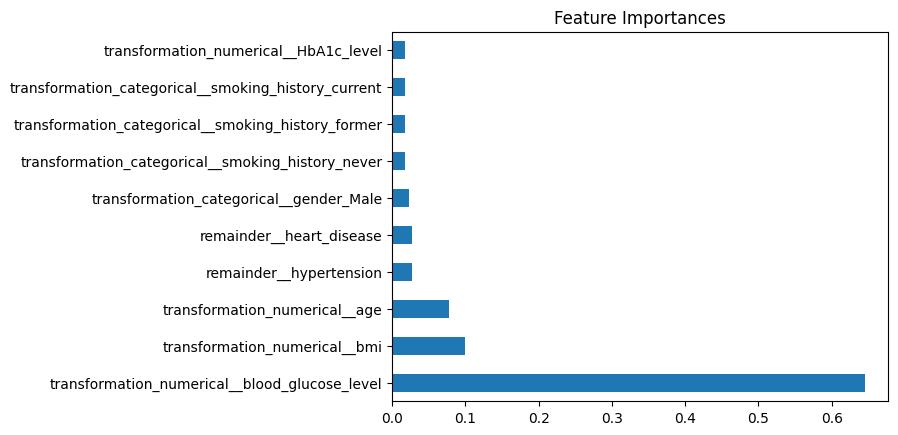

In [482]:
feature_imp = pd.Series(best_model['model'].feature_importances_, transformer.get_feature_names_out()).sort_values(ascending = False).head(10)
feature_imp.plot(kind='barh', title='Feature Importances')
plt.show()

Berdasarkan plot di atas, dengan menggunakan model Adaboost dapat dilihat bahwa fitur blood_glucose_level merupakan fitur yang paling penting dalam mempengaruhi prediksi diabetes.

## Kesimpulan

Berdasarkan *Classification Report* dapat disimpulkan bahwa:
* Adaboost memiliki nilai *precision*, *recall*, *f1-score*, dan skor ROC AUC yang paling baik sehingga dipakai sebagai model akhir.
* Model yang dipakai memiliki ketepatan sebesar 46%, artinya setiap kali model melakukan prediksi seseorang menderita diabetes, maka kemungkinan prediksi tersebut benar adalah sebesar 46%.
* Fitur yang paling mempengaruhi prediksi seseorang menderita diabetes adalah kadar gula darah.